Dataset: https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database

Citation: -M.E.H. Chowdhury, T. Rahman, A. Khandakar, R. Mazhar, M.A. Kadir, Z.B. Mahbub, K.R. Islam, M.S. Khan, A. Iqbal, N. Al-Emadi, M.B.I. Reaz, M. T. Islam, “Can AI help in screening Viral and COVID-19 pneumonia?” IEEE Access, Vol. 8, 2020, pp. 132665 - 132676. Paper link
-Rahman, T., Khandakar, A., Qiblawey, Y., Tahir, A., Kiranyaz, S., Kashem, S.B.A., Islam, M.T., Maadeed, S.A., Zughaier, S.M., Khan, M.S. and Chowdhury, M.E., 2020. 

Goal: Create a model with reasonable performance that predicts whether patient has COVID-19 based on their Chest X-ray

Acknowledgements: Special thanks to the Udemy Course Deep Learning with PyTorch for Medical Image Analysis by Jose Portilla and team. Also, Claude AI for providing coding insights and answering my questions on how to best achieve my goal and understand the processes along the way. 

Status: IN PROGRESS

In [2]:
#Importing packages

#need for data manipulation (merging datasets)
import pandas as pd

#merging folders 
import os
import shutil

#using machine learning model tools
from sklearn.model_selection import train_test_split

#plotting the medical images
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

#finding the std and mean
import cv2
from tqdm import tqdm
import numpy as np

In [ ]:
#Reading the csv file containing the results of Chest X-ray image

Positives=pd.read_excel(r"Drive:\Folder\Folder\COVID.metadata.xlsx")

#Reading the normal chest x-ray data
Negatives=pd.read_excel(r"Drive:\Folder\Folder\Normal.metadata.xlsx")


Section 2: To make it easier to run the model, we can merge both Negatives and Positives into one big dataset within the excel file. However, this is only the Excel file, we need to do the same for our chest-xray image files located in two folders. 

In [3]:
#See the first columns and rows to of the dataset to make sure our merge is clean

Positives.head()


,FILE NAME,FORMAT,SIZE,URL
0,COVID-1,PNG,256*256,https://sirm.org/category/senza-categoria/covi...
1,COVID-2,PNG,256*256,https://sirm.org/category/senza-categoria/covi...
2,COVID-3,PNG,256*256,https://sirm.org/category/senza-categoria/covi...
3,COVID-4,PNG,256*256,https://sirm.org/category/senza-categoria/covi...
4,COVID-5,PNG,256*256,https://sirm.org/category/senza-categoria/covi...


In [4]:
#See the first columns and rows to of the dataset to make sure our merge is clean
Negatives.head()

,FILE NAME,FORMAT,SIZE,URL
0,NORMAL-1,PNG,256*256,https://www.kaggle.com/c/rsna-pneumonia-detect...
1,NORMAL-2,PNG,256*256,https://www.kaggle.com/c/rsna-pneumonia-detect...
2,NORMAL-3,PNG,256*256,https://www.kaggle.com/c/rsna-pneumonia-detect...
3,NORMAL-4,PNG,256*256,https://www.kaggle.com/c/rsna-pneumonia-detect...
4,NORMAL-5,PNG,256*256,https://www.kaggle.com/c/rsna-pneumonia-detect...


In [5]:
#lists the number of rows so we can double check after merge that we have all the rows if we are doing a 
# a data stack on postives and negatives. So should be 3616 + 10192=13808

print("Positive rows:", len(Positives))
print("Negative rows:", len(Negatives))


Positive rows: 3616
Negative rows: 10192


In [6]:
#Both have the same column names thus, we can merge without data cleaning
Merge= pd.concat([Positives,Negatives], ignore_index=True)
#prints out the shape or rows,columns. We can see we have 13,808 rows and 4 columns which shows a clean
#stacking of the rows from positives and negatives

print(Merge.shape)

(13808, 4)


As we can see, there are two folders with Positive COVID-19 and Negative Chest X-rays. We need to merge so we can do a train-test split of 80 to 20. What this means is that we need to randomly select 80 percent of our Chest X-ray images as training images to feed into our model to train it. Then, the remaining 20% of the Chest X-ray images that the model hasn't seen yet is fed so we can evaluate the model. Another thing to note is that the COVID-19 Chest X-ray starts from 1 and the Normal Chest X-ray starts at 1. If we presume that each chest x-ray image is a unique patient, we need to renumber the chest-xray image so that when we merge the two folders we would have COVID-19_2091 and then Normal_2092; instead of COVID-19_2091 then Normal_1. 

In [ ]:
#Merging two folders

#location of our Positive Chest X-ray Folder
Positive_Folder= r"Drive:\Folder\Folder\COVID\images"
#location of our Negative Chest X-ray Folder
Negative_Folder= r"Drive:\Folder\Folder\Normal\images"

#Location of where we wish to put our output folder
Output_Folder= r"Drive:\Folder\Folder\COVID19_Merged"

#this code creates the Output_Folder if it doesn't exist. Exist_ok=True means don't do anything if it already exists because without this code,
#we would get an error
os.makedirs(Output_Folder,exist_ok=True)

#setting up our lists. So that if a file gets skipped or copied, it is inputted into these lists 

skipped = []

copied = []

counter = 1 #single counter for both folders

#looping through each folder
for folder in [Positive_Folder,Negative_Folder]:
    #looping through each file of the folder
    for file in os.listdir(folder):
        if file.endswith(".png"): # only use png images

            
            # Finding the prefix (hardcoded which means that folder 1 has to be COVID-19 images first)

            source = os.path.join(folder,file) #where file comes from
            destination=os.path.join(Output_Folder,file) #where file is going to 
            #If the file is already in the destination, skip it
            if os.path.exists(destination):
                skipped.apend(file) 
                #if not copy it 
            else:
                shutil.copy2(source,destination) 
                copied.append(file)





Copied: 13808 files
Skipped: 0 files that already exists
In Merged Folder: 13808 files


In [8]:
#Counts how many files were copied, skipped, and in the merged folder
print(f"Copied: {len(copied)} files")
print(f"Skipped: {len(skipped)} files that already exists")
print(f"In Merged Folder: {len(os.listdir(Output_Folder))} files")


Copied: 13808 files
Skipped: 0 files that already exists
In Merged Folder: 13808 files


Now that we've merged the photos in the folder. We need to split the folders into training and testing images. We need to create a model using the training chest X-ray data. Then, evaluate our model by feeding in the testing images that the model hasn't seen before. 

In [ ]:
merged_folder = r"Drive:\Folder\Folder\COVID19_Merged"
training_folder = r"Drive:\Folder\Folder\COVID19_training_folder"
testing_folder = r"Drive:\Folder\Folder\COVID19_testing_folder"


os.makedirs(training_folder, exist_ok=True)
os.makedirs(testing_folder,exist_ok=True)

#obtain all files from the folder so we can use the variable to be inputed into the next function code 
all_files = [f for f in os.listdir(merged_folder) if f.endswith(".png")]

train_files, test_files = train_test_split(
    all_files,
    test_size=0.2, #20 percent of testing
    random_state=42 #makes randomization reproducible so we would get the "same" randomization order
)

#Move the files one by one that we chose in train_test_split from Merged Folder to Train or Test Folder

for file in train_files: 
    shutil.copy2(os.path.join(merged_folder,file), # From Merged
                 os.path.join(training_folder, file)) # To Train
    
for file in test_files: 
    shutil.copy2(os.path.join(merged_folder,file), #From Merged
                 os.path.join(testing_folder,file)) #To Testing
    


In [ ]:
#Prints out total of images from all files, training, and testing files.

print(f"Total Images: {len(all_files)}")
print(f"Total Training Images: {len(train_files)}") 
print(f"Total Testing Images: {len(test_files)}")

Total Images: 13808
Total Training Images: 11046
Total Testing Images: 2762


We are using 13808 files so 20% which is our testing images should be 13808 * .20 = ~2762. This is what we have. 

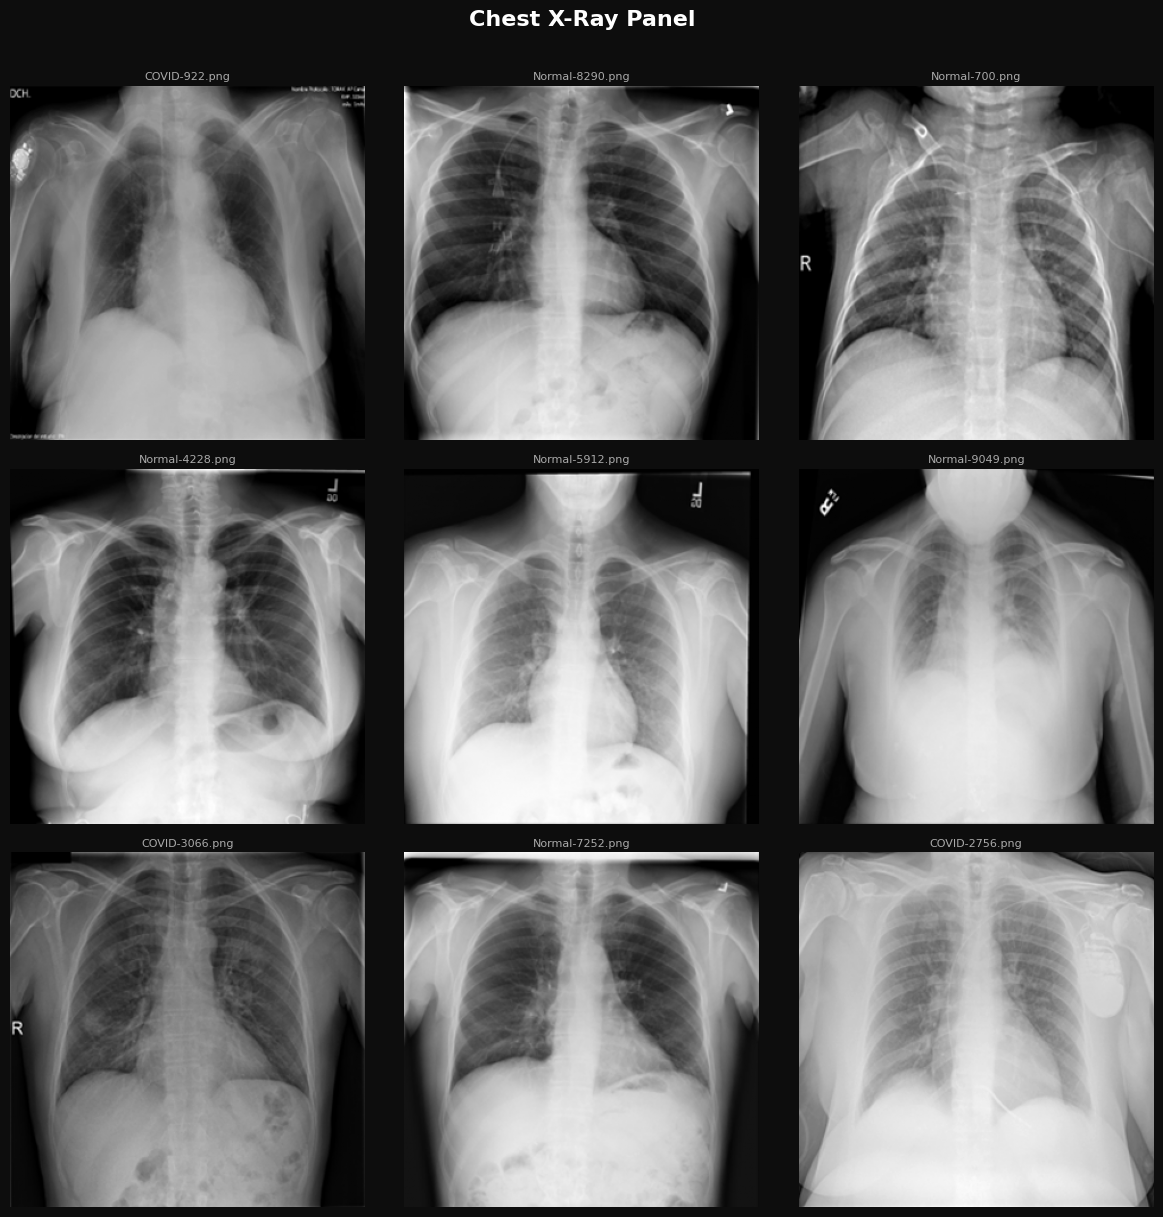

In [ ]:
#Let's plot a 3x3 of the first 9 what the files looks like

#Where the file pathway is located 
folder_path=r"Drive:\Folder\Folder\COVID19_training_folder"

#Obtain PNG files (random 9 images)

all_files = [
    os.path.join(folder_path, f)
    for f in sorted(os.listdir(folder_path))
    if f.lower().endswith('.png')
]
#get 9 randomly images
image_files = random.sample(all_files, min(9, len(all_files)))


# Plot 3x3 grid
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
fig.patch.set_facecolor('#0d0d0d')          # Dark background for the figure
fig.suptitle('Chest X-Ray Panel', 
             color='white', fontsize=16, fontweight='bold', y=1.01)

#i is our index(0-8 or our images), ax is the specific subplot

#┌─────────┬─────────┬─────────┐
#│  ax0    │  ax1    │  ax2    │
#├─────────┼─────────┼─────────┤
#│  ax3    │  ax4    │  ax5    │
#├─────────┼─────────┼─────────┤
#│  ax6    │  ax7    │  ax8    │
#└─────────┴─────────┴─────────┘

for i, ax in enumerate(axes.flatten()):
    ax.set_facecolor('#0d0d0d')             # Dark background per cell

    if i < len(image_files):
        img = mpimg.imread(image_files[i])
        # the ax.imshow or am.set_title loops through each ax image subplot 
        ax.imshow(img, cmap='gray')         # Grayscale colormap
        #sets titles
        ax.set_title(
            os.path.basename(image_files[i]),
            color='#aaaaaa', fontsize=8, pad=4
        )
    #hides borders
    ax.axis('off')

plt.tight_layout()
plt.show()

We can see that it's difficult to differentiate the COVID-19 and Normal Chest X-ray images. Also, there are a lot of variables that can cause biases (i.e. different lighting, blurriness, machine settings, etc.) Therefore, we standardize the pixel values of the images to get rid of biases so we can focus on it's contrasting patterns. 

For example, if all most our COVID-19 Chest X-ray images were bright, then without standardization, our model will "learn" that COVID-19 Chest X-ray images are brighter when in reality this was how the Chest X-ray was taken. By using standardization, we place all chest X-ray images in the same distribution or equal footing (in this case, same lighting distribution) so that the model will focus on other patterns.

Section 3: Finding the mean and standard deviation for our dataset to standardize our Chest X-ray images.

Each Chest X-ray can have different brightness due to the different machines used. By standardizing each chest x-ray, we can reduce Bias. For this section, we need to find the mean and standard deviation to  plug into a transform function (next section) and have each image be loaded and standardize. The Z formula which the transform function does in the backend is shown: 

           X-μ​
      Z=  -----
            σ

For example: if we have one chest x-ray image that consists of multiple pixel values 

      0.3  0.5  0.8  0.6
      0.4  0.7  0.5  0.3
      0.6  0.5  0.4  0.7
      0.8  0.3  0.6  0.5

Then, after standardization it would change to: 
 
        -1.0  0.0   1.5  0.5
        -0.5  1.0   0.0 -1.0
         0.5  0.0  -0.5  1.0
         1.5 -1.0   0.5  0.0

If we focus on how pixel number 0.3 -> -1.0 (upper left corner) with mean=0.5 and standard deviation 0.2 we would have formula below: 

Z= (0.3-0.5)/0.2

Z= -1.0

Standardization is helpful as our main goal is to see differences of pixel values (something that's hard to see with the naked eye for health professionals). So, we can say that Healthy lung pixels have low z-score with low or no normal brightness (Z~0). Whereas, those with bright pixels with high Z-score could be those with a positive chest X-ray. 

In [ ]:
#sets up the sums and sums squared variables 

sums= 0 

sums_squared = 0

for filename in tqdm(all_files):
    #Normalize each image's pixel from 0 to 1. Since PNG pixel values range from 0 black, 128 mid-gray, and 255 pure white; dividing by the max (255) can normalize the pixel values from 0 to 1.
    img = mpimg.imread(os.path.join(folder_path,filename))
    # PNG can have two different scales. If img.max() >1.0 then it needs to be standardize since it's pixel range is from 0 to 255. Whereas, a img.max of <1.0 means that it's already standarize with pixel range from 0 to 1.0
    if img.max() > 1.0:
        img = img / 255.0

    #resize image to 224 x 224. This is fixing the resolution
    img = cv2.resize(img, (224,224)).astype(np.float32)

    #Normalizer = total pixels per image (224x224) This is standardizing each pixel
    normalizer = img.shape[0] * img. shape [1]

    #accumulate running sums
    sums += np.sum(img)/normalizer
    sums_squared += (np.power(img,2).sum())/normalizer

    #Compute the total mean and standard deviation of all files

    num_images = len(all_files)

    mean=sums/ num_images

    std= np.sqrt((sums_squared/num_images) - (mean ** 2))

#print the numbers .4f is 4 decimale placers
print(f"Number of images: {num_images}")
print(f"Mean: {mean:.4f}")
print(f"Std: {std:.4f}")


    

100%|██████████| 11046/11046 [00:13<00:00, 807.57it/s]

Number of images: 11046
Mean: 0.5177
Std: 0.2555


#We have found the standard deviation and mean. We will now move on to the transformers where it will apply the Z formula to each image and alter the pixel values to standardize the images.

Section 4: Using a Transformer to normalizing the pixels of Chest X-ray images through the Z formula.

In [ ]:
#Transformer Code 



